# Annotated StockMixer

本 notebook 参照 AAAI 2024 论文 **StockMixer: A Simple Yet Strong MLP-Based Architecture for Stock Price Forecasting** 与官方代码实现，解释 StockMixer 如何用 MLP 风格的 mixing 结构完成股票收益预测。

论文链接：本目录 PDF [2024-AAAI-StockMixer.pdf](./2024-AAAI-StockMixer.pdf)  
官方代码：https://github.com/SJTU-Quant/StockMixer


## 1. 学习目标

本节围绕一个问题展开：**如何把一组股票的历史日频指标映射为下一交易日收益率预测，并用横截面排序指标评价模型是否有选股价值。**

学习完成后，你将能够：

- 说明 StockMixer 的输入 $X \in \mathbb{R}^{N\times T\times F}$ 在金融语境中的含义
- 区分 indicator mixing、time mixing、stock mixing 分别捕捉哪一类相关性
- 理解多尺度时间 patch 与上三角时间混合（TriU）为什么适合短窗口股票序列
- 写出 $\mathcal{L}_{\mathrm{MSE}}+\alpha\mathcal{L}_{\mathrm{rank}}$ 的训练目标，并解释它与选股排序的关系
- 用轻量示例验证模型前向传播、损失计算、训练循环和可视化


## 2. 研究背景与直觉

股票价格预测不是单只股票的孤立时间序列问题。论文把有效信息拆成三类相关性：

- **指标相关性（indicator correlation）**：同一天的开盘价、最高价、最低价、收盘价、均价等指标之间存在关系。例如收盘价相对开盘价的位置可能反映当日买卖压力。
- **时间相关性（temporal correlation）**：最近几个交易日的走势会影响下一日预期，但股票日频序列通常短、噪声大、非平稳，不像电力或交通数据那样有稳定周期。
- **股票相关性（stock correlation）**：同一市场中的股票受行业、风险偏好、流动性和市场状态共同影响。StockMixer 不依赖外部图，而是让模型学习“股票 -> 市场状态 -> 股票”的信息通路。

量化任务的目标不是只让价格数值误差最小，而是要让预测排序对选股有用。因此 notebook 会同时关注回归误差、横截面相关性和 top-k 股票的收益方向。


## 3. 任务定义

论文中的监督学习任务可以写成：

$$
X \in \mathbb{R}^{N\times T\times F}\ \xrightarrow{\theta}\ \hat{p}\in\mathbb{R}^{N\times 1}\ \rightarrow\ \hat{r}\in\mathbb{R}^{N\times 1}
$$

其中：

- $N$：同一市场中的股票数量，例如 NASDAQ 为 1026 只股票
- $T$：回看窗口长度，论文和官方代码使用 $T=16$ 个交易日
- $F$：每只股票每天的指标数，官方预处理数据中为 $F=5$
- $p_{i,t-1}$：第 $i$ 只股票在窗口最后一天的基准价格
- $r_{i,t}$：下一交易日真实收益率

官方训练代码先预测下一交易日价格 $\hat{p}_{i,t}$，再换算预测收益率：

$$
\hat{r}_{i,t}=\frac{\hat{p}_{i,t}-p_{i,t-1}}{p_{i,t-1}}
$$

在量化解释上，模型输出的 $\hat{r}$ 是一个横截面打分：每天对所有可交易股票排序，靠前股票被视为更值得买入或纳入组合。


## 4. 数据集介绍

论文使用三个美股日频数据集：NASDAQ、NYSE 和 S&P500。官方代码中 NASDAQ 预处理后的文件包括：

- `eod_data.pkl`：形状 `(1026, 1245, 5)`，即股票、交易日、指标
- `mask_data.pkl`：形状 `(1026, 1245)`，标记某只股票某天是否有效
- `gt_data.pkl`：形状 `(1026, 1245)`，下一期收益率标签
- `price_data.pkl`：形状 `(1026, 1245)`，用于从预测价格换算收益率

论文数据划分如下：

| 数据集 | 股票数 | 起始日期 | 结束日期 | 训练日 | 验证日 | 测试日 |
|---|---:|---|---|---:|---:|---:|
| NASDAQ | 1026 | 2013-01-02 | 2017-12-08 | 756 | 252 | 273 |
| NYSE | 1737 | 2013-01-02 | 2017-12-08 | 756 | 252 | 273 |
| S&P500 | 474 | 2016-01-04 | 2022-05-25 | 1006 | 253 | 352 |

本 notebook 的可运行示例直接加载参考代码仓库中的 NASDAQ 预处理数据，并默认使用全量 1026 只股票。训练回合数使用官方代码中的 `epochs = 100`。如果要严格复现论文表格，还应使用多次随机种子、相同评估协议和一致的运行环境，并保持时间顺序划分，避免未来信息泄漏。


## 5. 指标介绍

StockMixer 的评价关注“预测值是否能帮助选股”。常见指标包括：

- **MSE**：预测收益率与真实收益率的均方误差，衡量点预测是否接近真实收益。
- **IC（Information Coefficient）**：每天横截面上预测收益与真实收益的 Pearson 相关系数，再对多天取平均。IC 越高，说明预测分数越能解释真实收益。
- **RIC / Rank IC**：论文文字描述为基于排序的相关性，衡量股票短期收益潜力排序是否一致。官方代码中的 `RIC` 实现是 $\operatorname{mean}(IC) / \operatorname{std}(IC)$，更接近 IC 稳定性比率；复现实验时需要明确采用哪一种定义。
- **Precision@$N$**：取预测排名前 $N$ 的股票，统计真实收益为正的比例。例如 Precision@10=0.6 表示前 10 只中有 6 只下一期收益为正。
- **Sharpe Ratio**：用组合收益均值除以波动率，衡量收益与风险的权衡。官方代码中用 top-5 等权收益近似计算。

这些指标与金融验证路径对应：MSE 看回归精度，IC/Rank IC 看横截面排序，Precision@N 看多头选股命中率，Sharpe 看简单策略收益风险比。


## 6. 模型架构

StockMixer 的主线是：先在单只股票内部混合指标与时间信息，再在所有股票之间学习市场状态影响。下面的整体流程图描述金融任务视角：从历史窗口到个股表示，再到市场影响和预测收益率。

```mermaid
flowchart LR
    A[历史窗口 X: N x T x F] --> B[Conv1d 下采样]
    A --> C[MultiTime2dMixer]
    B --> C
    C --> D[channel_fc]
    D --> E[个股表示 y: N x d]
    E --> F[NoGraphStockMixer]
    E --> G[time_fc]
    F --> H[time_fc_market]
    G --> I[预测价格]
    H --> I
    I --> J[预测收益率与排序]
```

模型-组件树状图使用代码中的类名，便于把论文概念映射到实现：

```mermaid
flowchart TD
    S[StockMixer]
    S --> Conv[Conv1d]
    S --> MT[MultiTime2dMixer]
    S --> CFC[channel_fc: Linear]
    S --> NG[NoGraphStockMixer]
    S --> TFC[time_fc: Linear]
    S --> TFCM[time_fc_market: Linear]

    MT --> MMain[Mixer2dTriU: main_mixer]
    MT --> MScale[Mixer2dTriU: scale_mixer]

    MMain --> TriU1[TriU]
    MMain --> MB1[MixerBlock]
    MScale --> TriU2[TriU]
    MScale --> MB2[MixerBlock]

    NG --> LN[LayerNorm]
    NG --> D1[dense1: Linear N to m]
    NG --> ACT[Hardswish]
    NG --> D2[dense2: Linear m to N]
```

张量流可以概括为：

| 阶段/模块 | 模块类名 | 输入形状 | 操作 | 输出形状 | 金融含义 |
|---|---|---|---|---|---|
| 原始窗口 | 数据输入 | `(N, T, F)` | 取同一天、同一股票的多个指标 | `(N, T, F)` | 每只股票最近 $T$ 天的价格/技术指标 |
| 下采样时间尺度 | `Conv1d` | `(N, T, F)` | 沿时间维做 `kernel_size=2, stride=2` 的局部压缩 | `(N, T/2, F)` | 得到两日 patch 级别的短趋势 |
| time mixing | `TriU` | `(N, F, T)` 或 `(N, F, T/2)` | 只使用当前及过去时间点做因果时间混合 | `(N, F, T)` 或 `(N, F, T/2)` | 避免未来时间泄漏，提取短窗口趋势 |
| indicator mixing | `MixerBlock` | `(N, T, F)` 或 `(N, T/2, F)` | 在 $F$ 维上做两层 MLP mixing | `(N, T, F)` 或 `(N, T/2, F)` | 学习开高低收等指标间关系 |
| time + indicator block | `Mixer2dTriU` | `(N, T, F)` 或 `(N, T/2, F)` | `LayerNorm -> TriU -> 残差 -> MixerBlock -> 残差` | `(N, T, F)` 或 `(N, T/2, F)` | 单只股票内部先提取时间趋势，再融合指标 |
| multi-scale patch | `MultiTime2dMixer` | `(N, T, F)` 与 `(N, T/2, F)` | 拼接原始尺度、主尺度混合结果、下采样尺度混合结果 | `(N, 2T+T/2, F)` | 同时观察日级变化和局部趋势 |
| channel compression | `channel_fc` | `(N, 2T+T/2, F)` | 将指标维 $F$ 压缩到 1 | `(N, 2T+T/2)` | 得到每只股票的时间表示 |
| stock mixing | `NoGraphStockMixer` | `(N, d)` | 股票到市场状态再回到股票，$d=2T+T/2$ | `(N, d)` | 学习横截面市场影响 |
| own prediction head | `time_fc` | `(N, d)` | 对个股自身表示做线性预测 | `(N, 1)` | 个股自身历史模式给出的价格预测 |
| market prediction head | `time_fc_market` | `(N, d)` | 对市场影响表示做线性预测 | `(N, 1)` | 市场状态修正后的价格预测 |
| final prediction | `StockMixer.forward` | `(N, 1)` 与 `(N, 1)` | 两个预测分支相加 | `(N, 1)` | 输出下一期价格，进而转为收益 |


## 7. 模型组件

下面的代码来自官方 `model.py` 的教学化改写。保留核心结构，但把注释重点放在张量形状和金融含义上。


In [1]:
import math
import pickle
import random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

SEED = 1234
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

### MixerBlock模块

MixerBlock 相当于一个两层 MLP，主要用于指标通道混合。输入张量的最后一维记为 $D$，可以是指标维 $F$，也可以是其他需要 mixing 的表示维度。

```mermaid
flowchart LR
    A[输入 x: ..., D] --> B[Linear: D -> H]
    B --> C[GELU]
    C --> D{dropout > 0?}
    D -->|是| E[Dropout]
    D -->|否| F[Linear: H -> D]
    E --> F
    F --> G{dropout > 0?}
    G -->|是| H[Dropout]
    G -->|否| I[输出: ..., D]
    H --> I
```

在 StockMixer 中，`MixerBlock(channels)` 用于 indicator mixing：对每个股票、每个时间位置上的 $F$ 个价格指标做非线性组合，输出形状保持不变，便于后续残差连接。


In [ ]:
class MixerBlock(nn.Module):
    """在最后一个维度做两层 MLP mixing。

    输入形状: (..., D)
    输出形状: (..., D)
    """
    
    def __init__(self, dim, hidden_dim=None, dropout=0.0):
        super().__init__()
        hidden_dim = hidden_dim or dim
        self.dense_1 = nn.Linear(dim, hidden_dim)
        self.activation = nn.GELU()
        self.dense_2 = nn.Linear(hidden_dim, dim)
        self.dropout = dropout
        
    def forward(self, x):
        x = self.dense_1(x)
        x = self.activation(x)
        if self.dropout:
            x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.dense_2(x)
        if self.dropout:
            x = F.dropout(x, p=self.dropout, training=self.training)
        return x

### TriU模块

TriU 是因果时间混合模块。输入形状为 `(N, F, T)`：$N$ 是股票数，$F$ 是指标通道数，$T$ 是回看窗口长度。对当前时间 $t$ 的输出，TriU 只读取输入的 $0..t$ 历史前缀，不读取未来时间 $t+1..T-1$。

```mermaid
flowchart LR
    X["inputs: N x F x T"] --> P0["inputs[:, :, 0:1]"]
    X --> P1["inputs[:, :, 0:2]"]
    X --> P2["inputs[:, :, 0:3]"]
    X --> PM["..."]
    X --> PT["inputs[:, :, 0:t+1]"]

    P0 --> L0["Linear 1 -> 1"]
    P1 --> L1["Linear 2 -> 1"]
    P2 --> L2["Linear 3 -> 1"]
    PM --> LM["..."]
    PT --> LT["Linear t+1 -> 1"]

    L0 --> Y0["y[:, :, 0]"]
    L1 --> Y1["y[:, :, 1]"]
    L2 --> Y2["y[:, :, 2]"]
    LM --> YM["..."]
    LT --> YT["y[:, :, t]"]

    Y0 --> C["cat over time"]
    Y1 --> C
    Y2 --> C
    YM --> C
    YT --> C
    C --> Y["output: N x F x T"]
```

图中的 `...` 表示中间时间位置重复相同模式。

金融含义上，TriU 强制每个交易日位置只利用当日及之前的走势信息。这相当于给时间 mixing 加上因果约束，避免模型在时间维上看到未来交易日。


In [ ]:

class TriU(nn.Module):
    """因果时间混合：第 t 个输出只看 0..t 的历史。

    输入形状: (N, F, T)
    输出形状: (N, F, T)
    """

    def __init__(self, time_steps):
        super().__init__()
        self.time_steps = time_steps
        self.tri_u = nn.ModuleList([nn.Linear(i + 1, 1) for i in range(time_steps)])

    def forward(self, inputs):
        pieces = []
        for i, layer in enumerate(self.tri_u):
            # inputs[:, :, :i+1] 的最后一维只包含当前及过去交易日。
            pieces.append(layer(inputs[:, :, : i + 1]))
        return torch.cat(pieces, dim=-1)

### Mixer2dTriU模块

Mixer2dTriU 把因果时间混合和指标通道混合组合在一起。输入形状为 `(N, T, F)`，其中 $N$ 是股票数，$T$ 是回看窗口长度，$F$ 是每个交易日的指标数。

代码中的顺序是：先用 `TriU` 沿时间维做因果 time mixing，再用 `MixerBlock` 沿指标维做 indicator mixing。两处残差连接保证输出形状仍是 `(N, T, F)`。

```mermaid
flowchart LR
    A["inputs: N x T x F"] --> B["LayerNorm over T,F"]
    B --> C["permute -> N x F x T"]
    C --> D["TriU time mixing"]
    D --> E["permute -> N x T x F"]
    E --> R1["add original inputs"]
    A --> R1
    R1 --> LN2["LayerNorm over T,F"]
    LN2 --> M["MixerBlock on F"]
    M --> R2["add time mixed x"]
    LN2 --> R2
    R2 --> Y["output: N x T x F"]
```

金融含义上，这个模块先在每只股票内部沿交易日方向提取短期趋势，再在同一交易日内融合开高低收等指标。这样既保留了时间因果性，也让不同价格指标能够相互校正。


In [ ]:
class Mixer2dTriU(nn.Module):
    """先做时间 mixing，再做指标 mixing，并保留残差。

    输入形状: (N, T, F)
    输出形状: (N, T, F)
    """
    def __init__(self, time_steps, channels):
        super().__init__()
        self.ln_1 = nn.LayerNorm([time_steps, channels])
        self.ln_2 = nn.LayerNorm([time_steps, channels])
        self.time_mixer = TriU(time_steps)
        self.channel_mixer = MixerBlock(channels)

    def forward(self, inputs):
        x = self.ln_1(inputs)          # (N, T, F)
        x = x.permute(0, 2, 1)         # (N, F, T)
        x = self.time_mixer(x)         # (N, F, T)
        x = x.permute(0, 2, 1)         # (N, T, F)

        x = self.ln_2(x + inputs)      # 时间混合残差
        y = self.channel_mixer(x)      # 指标维混合
        return x + y

### MultiTime2dMixer模块

MultiTime2dMixer 用来把不同时间尺度的表示拼接起来。它接收两个输入：

- `inputs`：原始窗口，形状 `(N, T, F)`
- `scaled_inputs`：由前面的 `Conv1d(kernel_size=2, stride=2)` 得到的下采样窗口，形状 `(N, T/2, F)`

两个尺度分别经过 `Mixer2dTriU`，然后与原始输入沿时间维拼接。输出形状为 `(N, 2T+T/2, F)`。当 $T=16$ 时，时间长度为 $16+16+8=40$。

```mermaid
flowchart LR
    A["inputs: N x T x F"] --> M1["Mixer2dTriU on T"]
    B["scaled_inputs: N x T/2 x F"] --> M2["Mixer2dTriU on T/2"]

    A --> C["concat over time"]
    M1 --> C
    M2 --> C
    C --> Y["output: N x (2T + T/2) x F"]
```

金融含义上，原始尺度保留逐日价格指标，`Mixer2dTriU(inputs)` 提取因果短期趋势，`Mixer2dTriU(scaled_inputs)` 提取两日 patch 级别的更粗趋势。拼接后，模型可以同时利用日级变化和局部趋势，减少单一时间尺度对噪声的敏感性。


In [ ]:
class MultiTime2dMixer(nn.Module):
    """原始尺度 + 下采样尺度的时间表示拼接。

    对 T=16 而言，官方代码使用一次 stride=2 的卷积得到 8 个时间 patch，
    最终长度 d = 16 + 16 + 8 = 40。
    """

    def __init__(self, time_steps, channels, scale_dim=8):
        super().__init__()
        self.main_mixer = Mixer2dTriU(time_steps, channels)
        self.scale_mixer = Mixer2dTriU(scale_dim, channels)

    def forward(self, inputs, scaled_inputs):
        x = self.main_mixer(inputs)            # (N, T, F)
        y = self.scale_mixer(scaled_inputs)    # (N, T/2, F)
        return torch.cat([inputs, x, y], dim=1) # (N, 2T+T/2, F)


### NoGraphStockMixer模块

NoGraphStockMixer 用来建模股票之间的横截面关系，但不依赖行业图、知识图谱或超图先验。输入形状为 `(N, d)`，其中 $N$ 是股票数，$d$ 是每只股票经过时间与指标混合后的表示长度。

代码先把张量转成 `(d, N)`，这样每个表示维度都能在 $N$ 只股票之间做 mixing。随后用 `Linear(N -> m)` 把所有股票压缩成 $m$ 个市场状态，再用 `Linear(m -> N)` 把市场状态映射回每只股票。NASDAQ 配置中 $m=20$。

```mermaid
flowchart LR
    A["inputs: N x d"] --> P["permute -> d x N"]
    P --> LN["LayerNorm over N"]
    LN --> S2M["Linear N -> m"]
    S2M --> M["market states: d x m"]
    M --> Act["Hardswish"]
    Act --> M2S["Linear m -> N"]
    M2S --> Z["stock effects: d x N"]
    Z --> P2["permute -> N x d"]
    P2 --> Y["output: N x d"]
```

金融含义上，这相当于让模型先从全市场股票表示中提炼少数市场状态，例如风险偏好、行业共振或流动性环境，再把这些状态反馈到每只股票。它不是显式股票图，但能学习“股票 -> 市场 -> 股票”的横截面影响。


In [ ]:
class NoGraphStockMixer(nn.Module):
    """不使用外部图结构的股票混合。

    输入形状: (N, d)
    输出形状: (N, d)

    先把每个时间表示维度上的 N 只股票压缩到 m 个市场状态，
    再把 m 个市场状态映射回 N 只股票。
    """
    def __init__(self, stocks, market_states=20):
        super().__init__()
        self.layer_norm_stock = nn.LayerNorm(stocks)
        self.dense1 = nn.Linear(stocks, market_states)
        self.activation = nn.Hardswish()
        self.dense2 = nn.Linear(market_states, stocks)
    
    def forward(self, inputs):
        x = inputs.permute(1, 0)       # (d, N)
        x = self.layer_norm_stock(x)
        x = self.dense1(x)             # (d, m)
        x = self.activation(x)
        x = self.dense2(x)             # (d, N)
        return x.permute(1, 0)         # (N, d)
    

### StockMixer模块

如前文所述，`StockMixer` 将各个组件放在一起，完成从历史窗口到下一交易日价格预测的完整 forward 流程。输入为 `inputs`，形状是 `(N, T, F)`。

1. 首先通过 `conv: Conv1d` 得到下采样时间尺度：`(N, T, F) -> (N, T/2, F)`。这里的下采样相当于构造两日 patch 级别的短趋势。
2. 然后通过 `mixer: MultiTime2dMixer` 进行不同尺度上的时间与指标融合：原始窗口、主尺度混合结果、下采样尺度混合结果会沿时间维拼接，得到 `(N, 2T+T/2, F)`。
3. 接着通过 `channel_fc: Linear` 压缩指标维：`(N, 2T+T/2, F) -> (N, 2T+T/2)`，得到每只股票的时间表示 $y$。
4. 再通过 `stock_mixer: NoGraphStockMixer` 建模横截面市场影响：`y -> z`，其中 $z$ 的形状仍为 `(N, 2T+T/2)`。
5. 最后用两个预测头分别给出个股自身预测和市场影响预测：`time_fc(y)` 与 `time_fc_market(z)` 都输出 `(N, 1)`，二者相加得到最终预测价格。



金融含义上，`StockMixer` 先学习每只股票自身的多尺度历史模式，再学习同一市场中股票之间的共同状态，最后把个股自身信号和市场影响信号合并为下一交易日价格预测。


In [ ]:
class StockMixer(nn.Module):
    """StockMixer 教学版，接口与官方实现保持一致。"""

    def __init__(self, stocks, time_steps, channels, market_states=20):
        super().__init__()
        assert time_steps % 2 == 0, "本教学实现假设 time_steps 可以被 2 整除。"
        scale_dim = time_steps // 2
        mixed_time_dim = time_steps * 2 + scale_dim

        self.conv = nn.Conv1d(channels, channels, kernel_size=2, stride=2)
        self.mixer = MultiTime2dMixer(time_steps, channels, scale_dim=scale_dim)
        self.channel_fc = nn.Linear(channels, 1)
        self.stock_mixer = NoGraphStockMixer(stocks, market_states)
        self.time_fc = nn.Linear(mixed_time_dim, 1)
        self.time_fc_market = nn.Linear(mixed_time_dim, 1)

    def forward(self, inputs):
        # inputs: (N, T, F)
        scaled = self.conv(inputs.permute(0, 2, 1)).permute(0, 2, 1) # (N, T/2, F)
        y = self.mixer(inputs, scaled)                               # (N, 2T+T/2, F)
        y = self.channel_fc(y).squeeze(-1)                           # (N, 2T+T/2)

        z = self.stock_mixer(y)                                      # (N, 2T+T/2)
        own_price = self.time_fc(y)                                  # (N, 1)
        market_adjustment = self.time_fc_market(z)                   # (N, 1)
        return own_price + market_adjustment


### 7.1 先用小张量检查每一层形状

下面用 `N=6, T=16, F=5` 的小输入跑一次前向传播。真实 NASDAQ 的 `N=1026`，但教学验证不需要先加载完整市场。


In [6]:
N, T, F_DIM = 6, 16, 5
sample_x = torch.randn(N, T, F_DIM)
model_shape_check = StockMixer(stocks=N, time_steps=T, channels=F_DIM, market_states=3)

with torch.no_grad():
    scaled = model_shape_check.conv(sample_x.permute(0, 2, 1)).permute(0, 2, 1)
    mixed = model_shape_check.mixer(sample_x, scaled)
    embedding = model_shape_check.channel_fc(mixed).squeeze(-1)
    stock_effect = model_shape_check.stock_mixer(embedding)
    prediction = model_shape_check(sample_x)

shape_table = pd.DataFrame({
    "张量": ["sample_x", "scaled", "mixed", "embedding", "stock_effect", "prediction"],
    "形状": [tuple(t.shape) for t in [sample_x, scaled, mixed, embedding, stock_effect, prediction]],
    "含义": [
        "股票 x 回看窗口 x 指标",
        "两日 patch 后的短趋势序列",
        "原始尺度、时间通道混合原始尺度、时间通道混合patch尺度拼接",
        "每只股票的时间表示",
        "市场状态反馈后的股票表示",
        "下一交易日价格预测",
    ],
})
shape_table


,张量,形状,含义
0,sample_x,"(6, 16, 5)",股票 x 回看窗口 x 指标
1,scaled,"(6, 8, 5)",两日 patch 后的短趋势序列
2,mixed,"(6, 40, 5)",原始尺度、时间通道混合原始尺度、时间通道混合patch尺度拼接
3,embedding,"(6, 40)",每只股票的时间表示
4,stock_effect,"(6, 40)",市场状态反馈后的股票表示
5,prediction,"(6, 1)",下一交易日价格预测


## 8. 损失函数定义

官方训练目标由两部分组成：

$$
\mathcal{L}=\mathcal{L}_{\mathrm{MSE}}+\alpha\mathcal{L}_{\mathrm{rank}}
$$

回归项比较预测收益率与真实收益率：

$$
\mathcal{L}_{\mathrm{MSE}}=\frac{1}{|\Omega|}\sum_i m_i(\hat{r}_i-r_i)^2
$$

排序项惩罚横截面相对顺序错误：

$$
\mathcal{L}_{\mathrm{rank}}=\frac{1}{N^2}\sum_i\sum_j\max\left(0, -(\hat{r}_i-\hat{r}_j)(r_i-r_j)\right)
$$

如果真实收益 $r_i > r_j$，但模型预测 $\hat{r}_i < \hat{r}_j$，乘积为负，排序项就会产生惩罚。这个设计直接服务于选股：不仅要预测数值，还要把高收益股票排到前面。


In [7]:
def stockmixer_loss(predicted_price, ground_truth_return, base_price, mask, alpha=0.1):
    """计算 MSE + pairwise rank loss。

    predicted_price: (N, 1)
    ground_truth_return: (N, 1)
    base_price: (N, 1)
    mask: (N, 1)，1 表示该股票当天有效
    """
    predicted_return = (predicted_price - base_price) / base_price
    valid_count = mask.sum().clamp_min(1.0)
    reg_loss = ((predicted_return - ground_truth_return).pow(2) * mask).sum() / valid_count

    pred_diff = predicted_return - predicted_return.T       # (N, N)
    gt_diff = ground_truth_return - ground_truth_return.T   # (N, N)
    pair_mask = mask @ mask.T                               # (N, N)
    rank_loss = F.relu(-pred_diff * gt_diff * pair_mask).mean()
    loss = reg_loss + alpha * rank_loss
    return loss, reg_loss, rank_loss, predicted_return


## 9. 模型训练过程

完整官方训练流程是：

1. 按交易日顺序划分训练、验证、测试，避免未来信息泄漏。
2. 对每个 offset 取 `eod_data[:, offset:offset+T, :]`，得到所有股票同一天的横截面样本。
3. 用窗口最后一天价格 `price_data[:, offset+T-1]` 作为基准价。
4. 用 `gt_data[:, offset+T]` 作为下一期收益率标签。
5. 前向得到预测价格，换算成预测收益率。
6. 用 $\mathcal{L}_{\mathrm{MSE}}+\alpha\mathcal{L}_{\mathrm{rank}}$ 更新模型。
7. 在验证集上选择最佳模型，并报告测试集 IC、Precision@10、Sharpe 等指标。

下面的示例使用真实 NASDAQ 预处理数据，并采用全量股票、参考代码的训练/验证时间边界，以及官方代码中的 `epochs = 100`。这会比轻量教学验证耗时更久，但训练回合数已经和论文代码一致。


In [9]:
def find_nasdaq_dataset_dir():
    """定位 NASDAQ 预处理数据目录。

    优先使用 notebook 旁边的相对路径；如果课程仓库没有复制数据，
    则读取参考代码仓库中的官方预处理数据。
    """
    candidates = [
        Path("dataset/NASDAQ"),
    ]
    required = ["eod_data.pkl", "mask_data.pkl", "gt_data.pkl", "price_data.pkl"]
    for data_dir in candidates:
        if all((data_dir / name).exists() for name in required):
            return data_dir
    raise FileNotFoundError("未找到 NASDAQ 预处理数据，请检查参考代码仓库或复制数据到 books/StockMixer/dataset/NASDAQ。")


def load_nasdaq_data(stock_subset=None):
    """加载 NASDAQ 真实预处理数据。

    stock_subset: 默认为 None，表示使用全部 1026 只股票；传入整数时可用于课堂调试子集。

    eod_data: (N, D, F)，股票、交易日、指标
    price_data: (N, D)，窗口最后一天基准价来自这里
    gt_data: (N, D)，第 t 天相对 t-1 天的真实收益率
    mask_data: (N, D)，1 表示该股票该交易日有效
    """
    data_dir = find_nasdaq_dataset_dir()
    with open(data_dir / "eod_data.pkl", "rb") as f:
        eod = pickle.load(f)
    with open(data_dir / "price_data.pkl", "rb") as f:
        price = pickle.load(f)
    with open(data_dir / "gt_data.pkl", "rb") as f:
        gt = pickle.load(f)
    with open(data_dir / "mask_data.pkl", "rb") as f:
        mask = pickle.load(f)

    if stock_subset is not None:
        eod = eod[:stock_subset]
        price = price[:stock_subset]
        gt = gt[:stock_subset]
        mask = mask[:stock_subset]

    return data_dir, eod.astype(np.float32), price.astype(np.float32), gt.astype(np.float32), mask.astype(np.float32)


data_dir, eod_data, price_data, gt_data, mask_data = load_nasdaq_data(stock_subset=None)
print("data_dir", data_dir)
print("eod_data", eod_data.shape, "price_data", price_data.shape, "gt_data", gt_data.shape, "mask_data", mask_data.shape)
print("mask coverage", float(mask_data.mean()))


data_dir dataset/NASDAQ
eod_data (1026, 1245, 5) price_data (1026, 1245) gt_data (1026, 1245) mask_data (1026, 1245)
mask coverage 0.9986472129821777


In [14]:
def get_batch(offset, eod_data, price_data, gt_data, mask_data, lookback=16, steps=1):
    """取某个交易日 offset 对应的横截面训练样本。"""
    seq = eod_data[:, offset : offset + lookback, :]                         # (N, T, F)
    valid = mask_data[:, offset : offset + lookback + steps].min(axis=1)     # (N,)
    base_price = price_data[:, offset + lookback - 1]                        # (N,)
    label_return = gt_data[:, offset + lookback + steps - 1]                 # (N,)
    return (
        torch.tensor(seq, dtype=torch.float32, device=device),
        torch.tensor(base_price[:, None], dtype=torch.float32, device=device),
        torch.tensor(label_return[:, None], dtype=torch.float32, device=device),
        torch.tensor(valid[:, None], dtype=torch.float32, device=device),
    )


def evaluate_cross_section(prediction, ground_truth, mask, top_k=10):
    """简化版横截面指标。输入形状都是 (N, num_days)。"""
    prediction = np.asarray(prediction)
    ground_truth = np.asarray(ground_truth)
    mask = np.asarray(mask)

    mse = np.sum(((prediction - ground_truth) * mask) ** 2) / np.maximum(mask.sum(), 1)
    ic_values, rank_ic_values, precision_values, topk_returns = [], [], [], []

    for day in range(prediction.shape[1]):
        valid = mask[:, day] > 0.5
        if valid.sum() < 3:
            continue
        pred = prediction[valid, day]
        gt = ground_truth[valid, day]
        ic_values.append(pd.Series(pred).corr(pd.Series(gt)))
        rank_ic_values.append(pd.Series(pred).rank().corr(pd.Series(gt).rank()))
        k = min(top_k, valid.sum())
        top_idx = np.argsort(pred)[-k:]
        precision_values.append(np.mean(gt[top_idx] > 0))
        topk_returns.append(np.mean(gt[top_idx]))

    topk_returns = np.asarray(topk_returns, dtype=float)
    sharpe = np.nan
    if topk_returns.size > 1 and topk_returns.std() > 1e-12:
        sharpe = topk_returns.mean() / topk_returns.std() * np.sqrt(252)

    return {
        "mse": mse,
        "IC": np.nanmean(ic_values),
        "RankIC": np.nanmean(rank_ic_values),
        f"precision@{top_k}": np.nanmean(precision_values),
        "sharpe_topk": sharpe,
    }


In [13]:
stocks, lookback, features = eod_data.shape[0], 16, eod_data.shape[-1]
valid_index, test_index, steps = 756, 1008, 1

model = StockMixer(stocks=stocks, time_steps=lookback, channels=features, market_states=20).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# 与参考代码一致：训练 offset 覆盖训练区间，验证 offset 从 valid_index 对应的标签日开始。
train_offsets = list(range(0, valid_index - lookback - steps + 1))
valid_offsets = list(range(valid_index - lookback - steps + 1, test_index - lookback - steps + 1))
alpha = 0.1
epochs = 100

history = []
for epoch in range(epochs):
    random.shuffle(train_offsets)
    model.train()
    total_loss = 0.0
    for offset in train_offsets:
        x, base_price, gt_return, valid_mask = get_batch(offset, eod_data, price_data, gt_data, mask_data, lookback)
        optimizer.zero_grad()
        predicted_price = model(x)
        loss, reg_loss, rank_loss, _ = stockmixer_loss(predicted_price, gt_return, base_price, valid_mask, alpha=alpha)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    history.append(total_loss / len(train_offsets))
    print(f"epoch {epoch + 1:02d} | train loss {history[-1]:.6f}")


epoch 01 | train loss 0.036434
epoch 02 | train loss 0.002261
epoch 03 | train loss 0.001748
epoch 04 | train loss 0.001502


## 10. 测试与结果解释

验证阶段按交易日逐日取横截面，得到形状 `(N, num_days)` 的预测收益矩阵和真实收益矩阵。这里的每一列对应一个交易日，每一行对应一只股票。


In [16]:
def predict_offsets(model, offsets):
    model.eval()
    pred_list, gt_list, mask_list = [], [], []
    with torch.no_grad():
        for offset in offsets:
            x, base_price, gt_return, valid_mask = get_batch(offset, eod_data, price_data, gt_data, mask_data, lookback)
            predicted_price = model(x)
            _, _, _, predicted_return = stockmixer_loss(predicted_price, gt_return, base_price, valid_mask, alpha=alpha)
            pred_list.append(predicted_return.squeeze(-1).cpu().numpy())
            gt_list.append(gt_return.squeeze(-1).cpu().numpy())
            mask_list.append(valid_mask.squeeze(-1).cpu().numpy())
    return np.stack(pred_list, axis=1), np.stack(gt_list, axis=1), np.stack(mask_list, axis=1)

pred_valid, gt_valid, mask_valid = predict_offsets(model, valid_offsets)
metrics = evaluate_cross_section(pred_valid, gt_valid, mask_valid, top_k=10)
pd.Series(metrics).to_frame("value")


,value
mse,0.001592
IC,0.018632
RankIC,0.017982
precision@10,0.509524
sharpe_topk,2.013238


指标解读时要注意两点：

- 这个示例使用真实 NASDAQ 全量股票和完整训练/验证 offset，但训练 epoch 少于论文正式实验，因此不能与论文表格直接比较。
- 在真实市场中，IC 很小也可能有意义。关键不是单日预测完全准确，而是长期横截面排序是否稳定、交易成本后是否仍有收益。


## 11. 可视化

先看训练 loss 是否下降，再看某一天的预测收益排序和真实收益排序。可视化的目的不是证明模型已经可交易，而是检查模型输出是否形成了可解释的横截面打分。


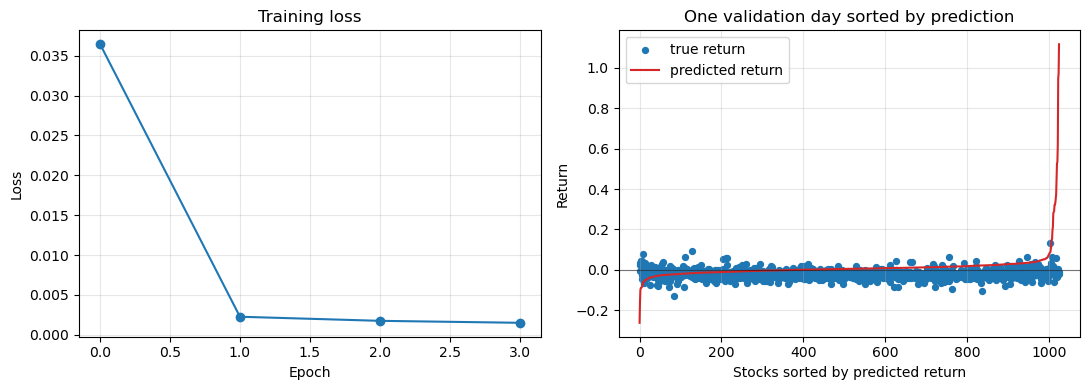

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].plot(history, marker="o")
axes[0].set_title("Training loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

plot_day = 0
order = np.argsort(pred_valid[:, plot_day])
axes[1].scatter(np.arange(stocks), gt_valid[order, plot_day], s=18, label="true return")
axes[1].plot(np.arange(stocks), pred_valid[order, plot_day], color="tab:red", linewidth=1.5, label="predicted return")
axes[1].axhline(0, color="black", linewidth=0.8, alpha=0.5)
axes[1].set_title("One validation day sorted by prediction")
axes[1].set_xlabel("Stocks sorted by predicted return")
axes[1].set_ylabel("Return")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


上图右侧按照模型预测收益从低到高排列股票。应重点观察：

- 右端高预测分数组中，真实收益是否更常为正
- 预测曲线是否出现极端异常值
- 真实收益点是否高度离散，提醒我们单日横截面噪声很大

如果在真实数据上长期看不到排序相关性，常见排查方向包括：标签是否错位、归一化是否泄漏未来、mask 是否正确、训练/验证/测试边界是否按交易日切分。


## 12. 小结

StockMixer 的核心价值不在于堆叠复杂结构，而是把股票预测中的三类相关性拆成轻量 mixing：

- indicator mixing 学习同一股票同一天的指标关系
- time mixing 用因果 TriU 和多尺度 patch 捕捉短窗口时间模式
- stock mixing 不依赖外部图，学习股票到市场状态再回到股票的横截面影响
- ranking-aware loss 让模型优化目标贴近选股排序，而不仅是价格回归

从量化验证角度，完整复现还需要固定数据版本、时间切分、交易假设、手续费滑点和多次随机种子。notebook 中的轻量示例只负责讲清楚张量如何流动，以及训练和评价闭环如何组织。

<details>
<summary>思考题：为什么不能随机打乱所有交易日后再划分训练集和测试集？</summary>

因为股票时间序列存在明显的时间依赖。随机划分会让训练集看到测试期附近甚至之后的市场状态，导致未来信息泄漏。量化实验应按交易日顺序划分，并在验证集上选择模型，最后只在测试集报告一次结果。

</details>

<details>
<summary>思考题：StockMixer 不使用行业图，是否意味着行业信息没有价值？</summary>

不是。StockMixer 的结论是：即使没有外部图，也可以通过 stock mixing 学习一部分市场共同状态。行业图、供应链图或新闻关系仍可能提供额外先验，但需要确认它们在样本外是否稳定、是否引入未来信息、是否覆盖所有股票。

</details>


## 13. 参考资料与延伸阅读

- Fan, Jinyong and Shen, Yanyan. **StockMixer: A Simple Yet Strong MLP-Based Architecture for Stock Price Forecasting**. AAAI 2024.
- 官方代码仓库：https://github.com/SJTU-Quant/StockMixer
- Feng et al. **Temporal Relational Ranking for Stock Prediction**，NASDAQ/NYSE 数据来源之一。
- Huynh et al. **Efficient Integration of Multi-Order Dynamics and Internal Dynamics in Stock Movement Prediction**，S&P500 数据来源之一。
- Tolstikhin et al. **MLP-Mixer: An all-MLP Architecture for Vision**，MLP mixing 思想来源之一。
- Zeng et al. **Are Transformers Effective for Time Series Forecasting?**，线性模型在时间序列预测中的代表性讨论。
